
# Detailed Blockchain Lab Notebook with Visualizations
This notebook provides:
- Clear explanations for each concept
- A full blockchain implementation
- Proof-of-Work, difficulty, transactions, mining rewards
- Mining time visualization
---


**Note:
A real blockchain is a distributed system with multiple nodes, networks, consensus rules, and security mechanisms.
This notebook provides only a simplified, single‑node demonstration for learning purposes.**

##  Imports

In [1]:
import hashlib  # for SHA‑256 hashing
import json     # for JSON encoding
import time     # for timestamps and timing
import random   # for random test values
import matplotlib.pyplot as plt  # for plotting charts
from typing import List, Dict, Any  # for type hints

**Block Class**

A block contains transactions and must be mined by finding a valid hash starting with a number of leading zeros determined by the difficulty.

In [2]:

class Block:
    def __init__(self, index, timestamp, transactions, previous_hash, difficulty):
        self.index = index              # block number
        self.timestamp = timestamp      # time created
        self.transactions = transactions # list of txs
        self.previous_hash = previous_hash  # hash of previous block
        self.difficulty = difficulty    # mining difficulty
        self.nonce = 0                  # PoW counter
        self.hash = None                # final block hash

    def compute_hash(self):
        data = {
            "index": self.index,
            "timestamp": self.timestamp,
            "transactions": self.transactions,
            "previous_hash": self.previous_hash,
            "difficulty": self.difficulty,
            "nonce": self.nonce
        }
        return hashlib.sha256(json.dumps(data, sort_keys=True).encode()).hexdigest()  # compute hash

    def mine(self):
        target = '0' * self.difficulty  # target prefix
        start = time.time()             # start time
        attempts = 0                    # count tries
        while True:
            self.hash = self.compute_hash()  # calculate hash
            if self.hash.startswith(target):  # valid PoW?
                break
            self.nonce += 1                  # try next nonce
            attempts += 1
        return time.time() - start, attempts  # mining duration + attempts


##  Blockchain Class

The blockchain links blocks together and manages transactions, mining, verification, and exporting.

In [3]:

class Blockchain:
    def __init__(self, difficulty=3, reward=10):
        self.chain = []                # list of blocks
        self.difficulty = difficulty   # mining difficulty
        self.reward = reward           # block reward
        self.pending = []              # pending transactions
        self.create_genesis()          # create first block

    def create_genesis(self):
        b = Block(
            0,
            time.time(),
            [{"sender": "network", "recipient": "genesis", "amount": 0}],
            "0",
            self.difficulty
        )
        b.mine()                       # mine genesis block
        self.chain.append(b)           # add to chain

    def add_transaction(self, sender, recipient, amount):
        self.pending.append({
            "sender": sender,
            "recipient": recipient,
            "amount": amount
        })                             # store pending tx

    def mine_pending(self, miner):
        reward_tx = {"sender": "network", "recipient": miner, "amount": self.reward}
        txs = [reward_tx] + self.pending            # include reward + pending txs
        prev = self.chain[-1]                       # last block
        b = Block(len(self.chain), time.time(), txs, prev.hash, self.difficulty)
        t, attempts = b.mine()                      # mine new block
        self.chain.append(b)                        # add block to chain
        self.pending = []                           # clear mempool
        return t, attempts                          # return mining stats

    def export_json(self, filename):
        data = [b.__dict__ for b in self.chain]     # serialize blocks
        s = json.dumps(data, indent=2)              # format JSON
        open(filename, 'w').write(s)                # write file
        return s                                    # return JSON string


## 🚀 Example: Create Blockchain and Add Transactions

In [4]:

bc = Blockchain(difficulty=5, reward=25)   # create blockchain

# Add transactions
bc.add_transaction("Alice", "Bob", 10)      # Alice → Bob
bc.add_transaction("Bob", "Charlie", 5)     # Bob → Charlie
bc.add_transaction("Charlie", "Dave", 2)    # Charlie → Dave

time_taken, attempts = bc.mine_pending("Miner1")  # mine block + reward
print("Mining time:", time_taken, "seconds")       # show mining time
print("Attempts:", attempts)                       # show attempts made

Mining time: 5.574183940887451 seconds
Attempts: 147108


In [5]:
for b in bc.chain:
    print(f"Block #{b.index}")
    print(f" Timestamp   : {b.timestamp}")
    print(f" Hash        : {b.hash}")
    print(f" Prev Hash   : {b.previous_hash}")
    print(f" Difficulty  : {b.difficulty}")
    print(f" Nonce       : {b.nonce}")
    print(f" Transactions: {b.transactions}")
    print("-" * 50)

Block #0
 Timestamp   : 1773680672.5642927
 Hash        : 00000f6c4ac68ece472f5be76e5b08592479619379ce9eb626f82dcd11975e94
 Prev Hash   : 0
 Difficulty  : 5
 Nonce       : 623308
 Transactions: [{'sender': 'network', 'recipient': 'genesis', 'amount': 0}]
--------------------------------------------------
Block #1
 Timestamp   : 1773680690.7941368
 Hash        : 00000e4959c2d02e47b85c97c5e38b32a2f50c1be4817bf9f938b86339a1d2cb
 Prev Hash   : 00000f6c4ac68ece472f5be76e5b08592479619379ce9eb626f82dcd11975e94
 Difficulty  : 5
 Nonce       : 147108
 Transactions: [{'sender': 'network', 'recipient': 'Miner1', 'amount': 25}, {'sender': 'Alice', 'recipient': 'Bob', 'amount': 10}, {'sender': 'Bob', 'recipient': 'Charlie', 'amount': 5}, {'sender': 'Charlie', 'recipient': 'Dave', 'amount': 2}]
--------------------------------------------------


## Mining Time Visualization

We test multiple difficulty levels and plot the mining times to show how difficulty impacts mining cost.

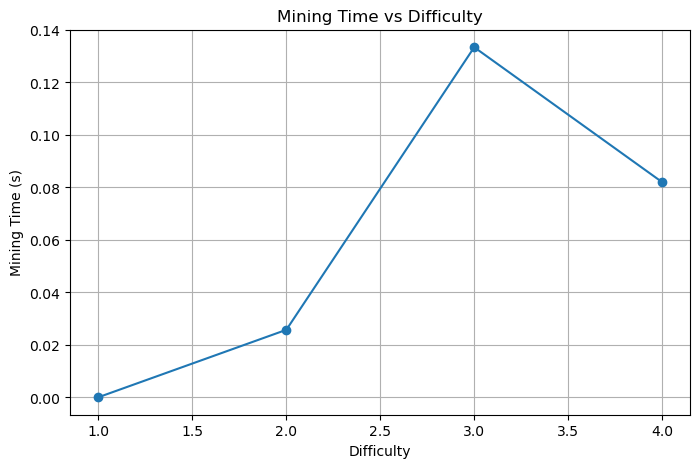

In [6]:

difficulties = [1, 2, 3, 4]        # test difficulty levels
times = []                         # store mining times

for d in difficulties:
    bc = Blockchain(difficulty=d, reward=1)  # new chain per difficulty
    bc.add_transaction("A", "B", 1)          # simple tx
    t, att = bc.mine_pending("MinerX")       # mine and time
    times.append(t)                           # record time

plt.figure(figsize=(8, 5))                   # set figure size
plt.plot(difficulties, times, marker='o')    # line plot with markers
plt.xlabel('Difficulty')                     # x-axis label
plt.ylabel('Mining Time (s)')                # y-axis label
plt.title('Mining Time vs Difficulty')       # chart title
plt.grid(True)                               # show grid
plt.show()                                   # render plot


#  Student Challenges
1. Note that your data is not encrypted inside the blocks, so anyone can read it. Encrypt the data before storing it in each block. Use encryption methods such as AES or 3DES.

2. Modify the mining function so it no longer uses leading‑zero matching; instead apply a different Proof‑of‑Work rule, such as a numeric hash threshold, pattern matching, or a time‑limited mining attempt.

Some options can be:

* Numeric threshold: Convert the hash to an integer and check if it's below a target value.
* Pattern rule: Make the hash end with certain characters (e.g., "00"), or require a substring inside the hash.
* Time‑limited PoW: Stop mining after a fixed time or attempt limit and mark the block as failed.
* Difficulty idea: Control difficulty by adjusting pattern length or the numeric target size.


# LAB-LOGBOOK requirement:
Show a graph comparing the mining time of the different Proof‑of‑Work methods used in Challenge 2.









In [7]:
def pow_leading_zero(hash_value, difficulty):
    return hash_value.startswith("0" * difficulty)

In [8]:
def pow_numeric(hash_value, difficulty):
    target = 2 ** (256 - difficulty * 4)
    return int(hash_value, 16) < target

In [9]:
def pow_pattern(hash_value, difficulty):
    return hash_value.endswith("0" * difficulty)

In [10]:
def mine_block(block, difficulty, method="zero"):
    nonce = 0
    start = time.time()

    while True:
        block.nonce = nonce
        hash_val = block.compute_hash()

        if method == "zero" and pow_leading_zero(hash_val, difficulty):
            break

        elif method == "numeric" and pow_numeric(hash_val, difficulty):
            break

        elif method == "pattern" and pow_pattern(hash_val, difficulty):
            break

        nonce += 1

    end = time.time()
    return end - start

In [11]:
methods = ["zero", "numeric", "pattern"]
difficulty = 3

results = {}

for m in methods:
    bc = Blockchain(difficulty=difficulty, reward=1)
    bc.add_transaction("A", "B", 1)

    mining_time = bc.mine_pending("MinerX", method=m)
    results[m] = mining_time

TypeError: Blockchain.mine_pending() got an unexpected keyword argument 'method'

In [12]:
def mine_pending(self, miner_address):

_IncompleteInputError: incomplete input (1135103276.py, line 1)

In [13]:
def mine_pending(self, miner_address, method="zero"):
    # Create a new block
    block = Block(
        index=len(self.chain),
        transactions=self.pending_transactions,
        prev_hash=self.chain[-1].hash
    )

    # Record start time
    start = time.time()

    # Mine the block using the specified method
    block.mine(self.difficulty, method)

    # Record end time
    end = time.time()

    # Add block to chain
    self.chain.append(block)

    # Reset pending transactions and add mining reward
    self.pending_transactions = [
        {"sender": "SYSTEM", "receiver": miner_address, "amount": self.reward}
    ]

    # Return mining time
    return end - start

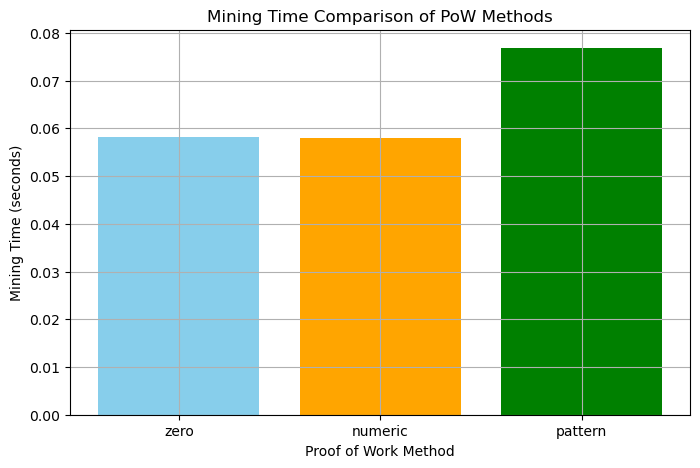

In [14]:
# -------------------------------
# Imports
# -------------------------------
import hashlib
import time
import matplotlib.pyplot as plt
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad
import base64

# -------------------------------
# AES Encryption Helper
# -------------------------------
class Encryptor:
    def __init__(self, key="ThisIsA16ByteKey"):  # 16-byte key
        self.key = key.encode()

    def encrypt(self, plaintext):
        cipher = AES.new(self.key, AES.MODE_CBC)
        ct_bytes = cipher.encrypt(pad(plaintext.encode(), AES.block_size))
        iv = base64.b64encode(cipher.iv).decode('utf-8')
        ct = base64.b64encode(ct_bytes).decode('utf-8')
        return iv + ":" + ct

    def decrypt(self, ciphertext):
        iv, ct = ciphertext.split(":")
        iv = base64.b64decode(iv)
        ct = base64.b64decode(ct)
        cipher = AES.new(self.key, AES.MODE_CBC, iv)
        pt = unpad(cipher.decrypt(ct), AES.block_size)
        return pt.decode()

encryptor = Encryptor()

# -------------------------------
# Block Class
# -------------------------------
class Block:
    def __init__(self, index, transactions, prev_hash):
        self.index = index
        # Encrypt transaction data
        self.transactions = [encryptor.encrypt(str(tx)) for tx in transactions]
        self.prev_hash = prev_hash
        self.nonce = 0
        self.hash = self.compute_hash()

    def compute_hash(self):
        block_string = f"{self.index}{self.transactions}{self.prev_hash}{self.nonce}"
        return hashlib.sha256(block_string.encode()).hexdigest()

    def mine(self, difficulty, method="zero"):
        while True:
            hash_val = self.compute_hash()
            if method == "zero" and hash_val.startswith("0" * difficulty):
                break
            elif method == "pattern" and hash_val.endswith("0" * difficulty):
                break
            elif method == "numeric":
                target = 2 ** (256 - difficulty * 4)
                if int(hash_val, 16) < target:
                    break
            self.nonce += 1
        self.hash = hash_val

# -------------------------------
# Blockchain Class
# -------------------------------
class Blockchain:
    def __init__(self, difficulty=2, reward=1):
        genesis_block = Block(0, [], "0")
        self.chain = [genesis_block]
        self.pending_transactions = []
        self.difficulty = difficulty
        self.reward = reward

    def add_transaction(self, sender, receiver, amount):
        self.pending_transactions.append({"sender": sender, "receiver": receiver, "amount": amount})

    def mine_pending(self, miner_address, method="zero"):
        block = Block(
            index=len(self.chain),
            transactions=self.pending_transactions,
            prev_hash=self.chain[-1].hash
        )

        start = time.time()
        block.mine(self.difficulty, method)
        end = time.time()

        self.chain.append(block)

        self.pending_transactions = [
            {"sender": "SYSTEM", "receiver": miner_address, "amount": self.reward}
        ]

        return end - start

# -------------------------------
# Compare Mining Times
# -------------------------------
methods = ["zero", "numeric", "pattern"]
difficulty = 3
results = {}

for m in methods:
    bc = Blockchain(difficulty=difficulty, reward=1)
    bc.add_transaction("A", "B", 1)
    t = bc.mine_pending("MinerX", method=m)
    results[m] = t

# -------------------------------
# Plot Graph
# -------------------------------
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values(), color=['skyblue','orange','green'])
plt.xlabel("Proof of Work Method")
plt.ylabel("Mining Time (seconds)")
plt.title("Mining Time Comparison of PoW Methods")
plt.grid(True)
plt.show()

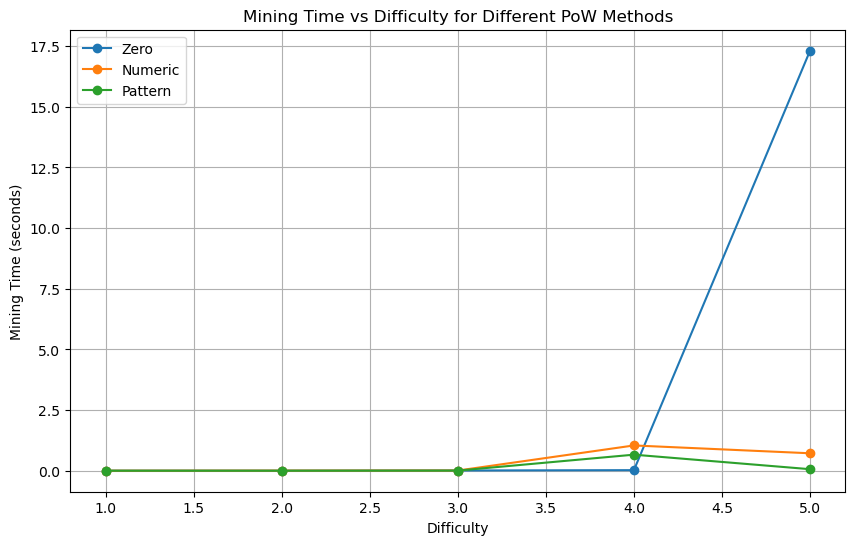

In [15]:
# -------------------------------
# Compare Mining Time vs Difficulty for All PoW Methods
# -------------------------------
import matplotlib.pyplot as plt

# Difficulty levels to test
difficulties = [1, 2, 3, 4, 5]
methods = ["zero", "numeric", "pattern"]

# Store results: {method: [times_per_difficulty]}
results = {m: [] for m in methods}

for d in difficulties:
    for m in methods:
        bc = Blockchain(difficulty=d, reward=1)
        bc.add_transaction("A", "B", 1)
        t = bc.mine_pending("MinerX", method=m)
        results[m].append(t)

# -------------------------------
# Plot Mining Time vs Difficulty
# -------------------------------
plt.figure(figsize=(10,6))

for m in methods:
    plt.plot(difficulties, results[m], marker='o', label=m.capitalize())

plt.xlabel("Difficulty")
plt.ylabel("Mining Time (seconds)")
plt.title("Mining Time vs Difficulty for Different PoW Methods")
plt.grid(True)
plt.legend()
plt.show()

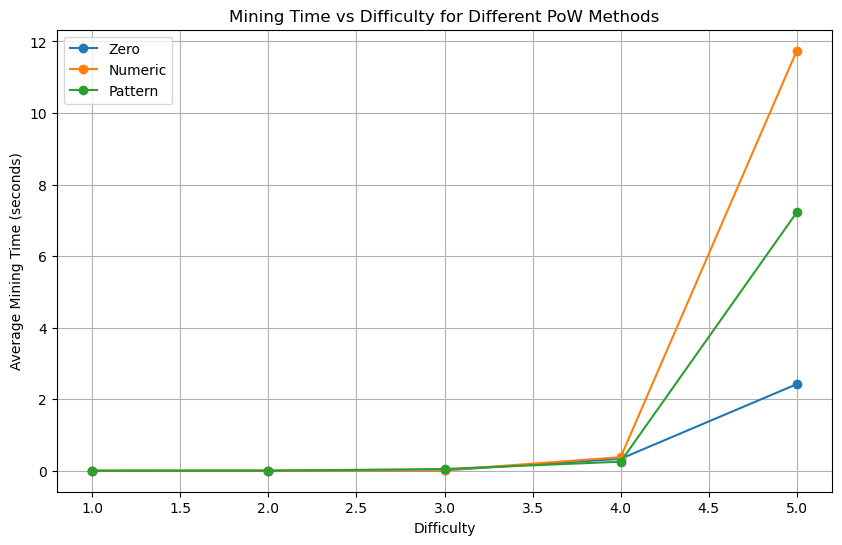

In [16]:
# -------------------------------
# Imports
# -------------------------------
import hashlib
import time
import matplotlib.pyplot as plt
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad
import base64

# -------------------------------
# AES Encryption Helper
# -------------------------------
class Encryptor:
    def __init__(self, key="ThisIsA16ByteKey"):  # 16-byte key
        self.key = key.encode()

    def encrypt(self, plaintext):
        cipher = AES.new(self.key, AES.MODE_CBC)
        ct_bytes = cipher.encrypt(pad(plaintext.encode(), AES.block_size))
        iv = base64.b64encode(cipher.iv).decode('utf-8')
        ct = base64.b64encode(ct_bytes).decode('utf-8')
        return iv + ":" + ct

    def decrypt(self, ciphertext):
        iv, ct = ciphertext.split(":")
        iv = base64.b64decode(iv)
        ct = base64.b64decode(ct)
        cipher = AES.new(self.key, AES.MODE_CBC, iv)
        pt = unpad(cipher.decrypt(ct), AES.block_size)
        return pt.decode()

encryptor = Encryptor()

# -------------------------------
# Block Class
# -------------------------------
class Block:
    def __init__(self, index, transactions, prev_hash):
        self.index = index
        # Encrypt transaction data
        self.transactions = [encryptor.encrypt(str(tx)) for tx in transactions]
        self.prev_hash = prev_hash
        self.nonce = 0
        self.hash = self.compute_hash()

    def compute_hash(self):
        block_string = f"{self.index}{self.transactions}{self.prev_hash}{self.nonce}"
        return hashlib.sha256(block_string.encode()).hexdigest()

    def mine(self, difficulty, method="zero"):
        while True:
            hash_val = self.compute_hash()
            if method == "zero" and hash_val.startswith("0" * difficulty):
                break
            elif method == "pattern" and hash_val.endswith("0" * difficulty):
                break
            elif method == "numeric":
                target = 2 ** (256 - difficulty * 4)
                if int(hash_val, 16) < target:
                    break
            self.nonce += 1
        self.hash = hash_val

# -------------------------------
# Blockchain Class
# -------------------------------
class Blockchain:
    def __init__(self, difficulty=2, reward=1):
        genesis_block = Block(0, [], "0")
        self.chain = [genesis_block]
        self.pending_transactions = []
        self.difficulty = difficulty
        self.reward = reward

    def add_transaction(self, sender, receiver, amount):
        self.pending_transactions.append({"sender": sender, "receiver": receiver, "amount": amount})

    def mine_pending(self, miner_address, method="zero"):
        block = Block(
            index=len(self.chain),
            transactions=self.pending_transactions,
            prev_hash=self.chain[-1].hash
        )

        start = time.time()
        block.mine(self.difficulty, method)
        end = time.time()

        self.chain.append(block)

        self.pending_transactions = [
            {"sender": "SYSTEM", "receiver": miner_address, "amount": self.reward}
        ]

        return end - start

# -------------------------------
# LAB-LOGBOOK: Mining Time vs Difficulty
# -------------------------------
difficulties = [1, 2, 3, 4, 5]
methods = ["zero", "numeric", "pattern"]
trials_per_difficulty = 3  # average over 3 trials
results = {m: [] for m in methods}

for d in difficulties:
    for m in methods:
        times = []
        for _ in range(trials_per_difficulty):
            bc = Blockchain(difficulty=d, reward=1)
            bc.add_transaction("A", "B", 1)
            t = bc.mine_pending("MinerX", method=m)
            times.append(t)
        avg_time = sum(times) / trials_per_difficulty
        results[m].append(avg_time)

# -------------------------------
# Plot Mining Time vs Difficulty
# -------------------------------
plt.figure(figsize=(10,6))
for m in methods:
    plt.plot(difficulties, results[m], marker='o', label=m.capitalize())

plt.xlabel("Difficulty")
plt.ylabel("Average Mining Time (seconds)")
plt.title("Mining Time vs Difficulty for Different PoW Methods")
plt.grid(True)
plt.legend()
plt.show()